In [ ]:
# after testing change the 20 labels to 1 label output
# before testing change test and validate split 

In [35]:
import meta
import load
import analysis
import preprocess
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
np.random.seed(42)

In [36]:
records = []

# dataset = meta.datasets[0]
# records.extend(load.load_dataset(dataset))

dateset = meta.datasets[1]
records.extend(load.load_dataset(dateset))

  0%|          | 0/25 [00:00<?, ?it/s]

Error processing record 00735: sampto must be greater than sampfrom
Error processing record 03665: sampto must be greater than sampfrom


100%|██████████| 25/25 [00:21<00:00,  1.18it/s]

Loaded 23 records from afdb dataset.


In [37]:
auxnote_override_map = defaultdict(lambda: "Other")
auxnote_override_map['(AFIB'] = "AF"
auxnote_override_map['(AFL'] = "AF"

analysis.print_records_annotations(records)
records = preprocess.remove_auxnote_by_identifier(records, start_id='(V')  # remove (V events
analysis.print_records_annotations(records)
records = preprocess.override_auxnote(records, auxnote_override_map)
analysis.print_records_annotations(records)

Counter({'(AFIB': 291, '(N': 288, '(AFL': 14, '(J': 12})
Counter({'(AFIB': 291, '(N': 288, '(AFL': 14, '(J': 12})
Counter({'AF': 305, 'Other': 300})


## Preprocess Data

In [38]:
records = preprocess.preprocess_records(records, frequency_resample=True, bandpass_filter=True)

100%|██████████| 23/23 [00:29<00:00,  1.30s/it]


## Generate Samples

In [ ]:
#stratify resample records based on AF label
pct_test = 0.2
from sklearn.model_selection import train_test_split
record_with_af = np.array([record['df_ann']['AuxNote'].str.contains("AF").any() for record in records])
records_train, records_test = train_test_split(records, stratify=record_with_af, test_size=pct_test, random_state=42)
print(f"Train records size: {len(records_train)}")
print(f"Test records size: {len(records_test)}")

records_train_names = [record['record_name'] for record in records_train]
records_test_names = [record['record_name'] for record in records_test]
print(f"Train records names: {records_train_names}")
print(f"Test records names: {records_test_names}")

Train records size: 18
Test records size: 5
Train records names: ['05261', '08434', '07910', '06995', '08215', '04126', '08219', '07162', '05121', '04043', '04015', '04048', '04746', '06453', '07879', '04908', '08455', '08405']
Test records names: ['04936', '08378', '06426', '07859', '05091']


In [ ]:
window_duration = 20  # seconds
stride_duration = 5  # seconds

auxnote_label_map = {"AF":1, "Other": 0}

freq_to_keeprate_map_train = {1:0.1, 2:1}
samples_train = preprocess.generate_samples_from_records(records_train, 
                                                    window_duration=window_duration, stride_duration=stride_duration, 
                                                    auxnote_label_map = auxnote_label_map, freq_to_keeprate_map = freq_to_keeprate_map_train)

freq_to_keeprate_map_test = {1:1, 2:1}
samples_test = preprocess.generate_samples_from_records(records_test,
                                                    window_duration=window_duration, stride_duration=window_duration, # non overlapping
                                                    auxnote_label_map = auxnote_label_map, freq_to_keeprate_map = freq_to_keeprate_map_test)


 35%|███▌      | 14915/42166 [01:10<02:12, 206.34it/s]

In [ ]:
# split the samples into train/test with 80/20
from sklearn.model_selection import train_test_split
samples_train, samples_test = train_test_split(samples, test_size=0.2, random_state=42)
print(f"Train samples size: {len(samples_train)}")
print(f"Test samples size: {len(samples_test)}")
print(f"Train samples labels: {Counter([sample['label'] for sample in samples_train])}")
print(f"Test samples labels: {Counter([sample['label'] for sample in samples_test])}")

In [41]:
def select_samples_by_label(samples, output_pct, output_size):
    samples_selected = []
    for label, pct in output_pct.items():
        num_samples = int(output_size * pct)
        label_samples = [sample for sample in samples if sample['labels'] == label]
        print(f"Resampling {len(label_samples)} samples to {num_samples} samples for label {label}")
        if len(label_samples) > num_samples:
            label_samples = np.random.choice(label_samples, size=num_samples, replace=False)
        elif len(label_samples) < num_samples:
            label_samples = np.random.choice(label_samples, size=num_samples, replace=True)
        samples_selected.extend(label_samples)
    return samples_selected

def print_sample_labels(samples):
    counter = Counter([sample['labels'] for sample in samples])
    print(f"Sample labels: {counter}")


In [42]:
print_sample_labels(samples_train)
print_sample_labels(samples_test)

Sample labels: Counter({'0': 8629, '1': 4589, '01': 1483})
Sample labels: Counter({'1': 5503, '0': 3567, '01': 135})


In [43]:
#pct_by_label = {'0':0.33, '1':0.33, '01':0.33}
pct_by_label = {'0':0.5, '1':0.5, '01':0.0}
num_train_samples = 5760 * 2  #min(counter_train.values()) * 3
num_test_samples = 1400 * 2   #min(counter_test.values()) * 3
samples_train_selected = select_samples_by_label(samples_train, pct_by_label, num_train_samples)
samples_test_selected = select_samples_by_label(samples_test, pct_by_label, num_test_samples)

# print the resampled label counters
# counter_train_selected = Counter([sample['labels'] for sample in samples_train_selected])
# counter_test_selected = Counter([sample['labels'] for sample in samples_test_selected])
# print(f"Selected train labels: {counter_train_selected}")
# print(f"Selected test labels: {counter_test_selected}")
print_sample_labels(samples_train_selected)
print_sample_labels(samples_test_selected)

Resampling 8629 samples to 5760 samples for label 0
Resampling 4589 samples to 5760 samples for label 1
Resampling 1483 samples to 0 samples for label 01
Resampling 3567 samples to 1400 samples for label 0
Resampling 5503 samples to 1400 samples for label 1
Resampling 135 samples to 0 samples for label 01
Sample labels: Counter({'0': 5760, '1': 5760})
Sample labels: Counter({'0': 1400, '1': 1400})


In [ ]:
# num_classes = len(auxnote_label_map)
# X_train, Y_train_class = preprocess.generate_inputs_from_samples(samples_train_selected)
# X_test, Y_test_class = preprocess.generate_inputs_from_samples(samples_test_selected)
# Y_train = preprocess.class_to_onehot(Y_train_class, num_classes=num_classes)
# Y_test = preprocess.class_to_onehot(Y_test_class, num_classes=num_classes)
# print(f"Train set shape: {X_train.shape}, {Y_train.shape}")
# print(f"Test set shape: {X_test.shape}, {Y_test.shape}")

100%|██████████| 11520/11520 [00:00<00:00, 21354.52it/s]


Generated 11520 samples
X shape: (11520, 4000) y shape: (11520, 20)


100%|██████████| 2800/2800 [00:00<00:00, 18514.45it/s]


Generated 2800 samples
X shape: (2800, 4000) y shape: (2800, 20)
Train set shape: (11520, 4000), (11520, 40)
Test set shape: (2800, 4000), (2800, 40)


In [63]:
num_classes = len(auxnote_label_map)
X_train, Y_train_class = preprocess.generate_inputs_from_samples(samples_train_selected)
X_test, Y_test_class = preprocess.generate_inputs_from_samples(samples_test_selected)

def find_most_common_label(Y_train_class):
    most_common_labels = []
    for row in Y_train_class:
        counter = Counter(row)
        most_common_label = counter.most_common(1)[0][0]
        most_common_labels.append(most_common_label)
    return np.array(most_common_labels).reshape(-1, 1)

Y_train = preprocess.class_to_onehot(find_most_common_label(Y_train_class), num_classes=num_classes)
Y_test = preprocess.class_to_onehot(find_most_common_label(Y_test_class), num_classes=num_classes)

print(f"Train set shape: {X_train.shape}, {Y_train.shape}")
print(f"Test set shape: {X_test.shape}, {Y_test.shape}")

100%|██████████| 11520/11520 [00:00<00:00, 124980.62it/s]


Generated 11520 samples
X shape: (11520, 4000) y shape: (11520, 20)


100%|██████████| 2800/2800 [00:00<00:00, 101690.66it/s]


Generated 2800 samples
X shape: (2800, 4000) y shape: (2800, 20)
Train set shape: (11520, 4000), (11520, 2)
Test set shape: (2800, 4000), (2800, 2)


## Training

In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalAveragePooling1D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def network(X_train, y_train, X_test, y_test,
             unit_size, class_size, class_weights,
             filter_sizes = {1:16, 2:32, 3:64}, kernel_sizes = {1:7, 2:5, 3:3}, dropout_rates={1:0.2, 2:0.2, 3:0.2},
             learning_rate=0.001, batch_size = 32, epochs=40, 
             loss_type='cross_entropy', modelCheckPoint=False):
    
    ####################################################################
    output_size = unit_size * class_size  # output size is the number of classes times the number of units
    print("Class Weights:", class_weights)
    
    def custom_loss(y_true, y_pred):
        if class_size != len(class_weights):
            raise ValueError("The length of class_weights must match the number of classes.")
        
        # Reshape tensors
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])

        loss = 0.0
        if loss_type == 'cross_entropy':
            for i in range(class_size):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        -y_true[:, :, i] * tf.math.log(y_pred[:, :, i] + 1e-15) # average loss across all samples and units
                    )
        elif loss_type == 'mse':
            for i in range(class_size):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        tf.square(y_true[:, :, i] - y_pred[:, :, i])  # average loss across all samples and units
                    )
        else:
            raise ValueError("Invalid loss type. Use 'cross_entropy' or 'mse'.")
        return loss

    def custom_accuracy(y_true, y_pred):
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])
        correct_predictions = tf.equal(tf.argmax(y_true, axis=2), tf.argmax(y_pred, axis=2))
        return tf.reduce_mean(tf.cast(correct_predictions, tf.float32)) # average accuracy across all samples and units

    ####################################################################
    inputs_cnn = Input(shape=(X_train.shape[1], 1))

    # Block 1
    x = Conv1D(filter_sizes[1], kernel_size=kernel_sizes[1], padding='same')(inputs_cnn)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[1])(x)

    # Block 2
    x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[2])(x)
    x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)

    # Block 3
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[3])(x)
    x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)

    # Final block
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = GlobalAveragePooling1D()(x)

    # Output layer
    outputs_cnn = Dense(output_size, activation='softmax')(x)

    optimizer = Adam(learning_rate=learning_rate)
    model = Model(inputs=inputs_cnn, outputs=outputs_cnn)
    model.compile(optimizer=optimizer, loss=custom_loss, metrics=[custom_accuracy])
    #model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # define callbacks for early stopping and saving the best model with lowest validation loss
    callbacks = [EarlyStopping(monitor='val_loss', patience=10)]
    if modelCheckPoint:
        callbacks.append(ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True))
    history=model.fit(X_train, y_train, epochs=epochs, 
                      callbacks=callbacks, batch_size=batch_size, validation_data=(X_test, y_test),
                      #class_weight=class_weights # assign class weights to the model 
                      ) 
    if modelCheckPoint:
        model.load_weights('best_model.h5')
    return (model, history)

In [65]:
model, history=network(X_train, Y_train, X_test, Y_test,
                       filter_sizes={1: 8, 2: 16, 3: 32},
                       kernel_sizes={1: 3, 2: 3, 3: 3}, 
                       dropout_rates={1: 0.3, 2: 0.3, 3: 0.3},
                       #unit_size=window_duration, 
                       unit_size=1, 
                       class_size=num_classes,
                       class_weights={0: 0.5, 1: 0.5},
                       learning_rate=0.0001, 
                       #batch_size=32,
                       batch_size=128,
                       epochs=10, 
                       loss_type='cross_entropy', modelCheckPoint=False)

Class Weights: {0: 0.5, 1: 0.5}
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - custom_accuracy: 0.5137 - loss: 0.3462 - val_custom_accuracy: 0.7084 - val_loss: 0.3450
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - custom_accuracy: 0.5790 - loss: 0.3402 - val_custom_accuracy: 0.4972 - val_loss: 0.3549
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - custom_accuracy: 0.6094 - loss: 0.3345 - val_custom_accuracy: 0.4972 - val_loss: 0.4032
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - custom_accuracy: 0.6309 - loss: 0.3301 - val_custom_accuracy: 0.4972 - val_loss: 0.4540
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - custom_accuracy: 0.6560 - loss: 0.3265 - val_custom_accuracy: 0.4972 - val_loss: 0.4893
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - custom_accuracy: 0.6651 - loss: 0.3246 - val_custom_accuracy: 0.4975 - val_loss: 0.5075
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - custom_accuracy: 0.6864 - loss: 0.3201 - val_custom_accuracy: 0.4982 - val_l

In [67]:
#model.summary()

### Error Analysis

Accuracy: 49.79%


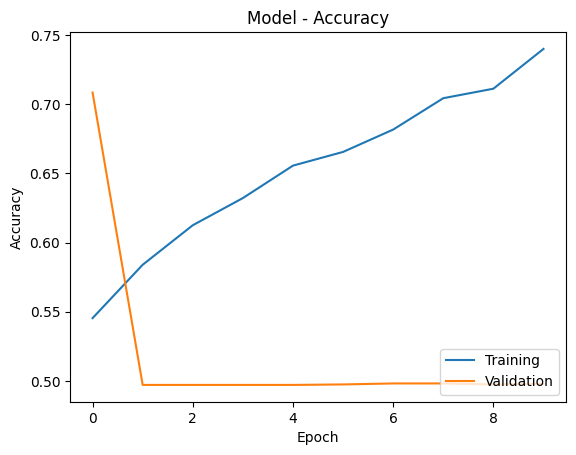

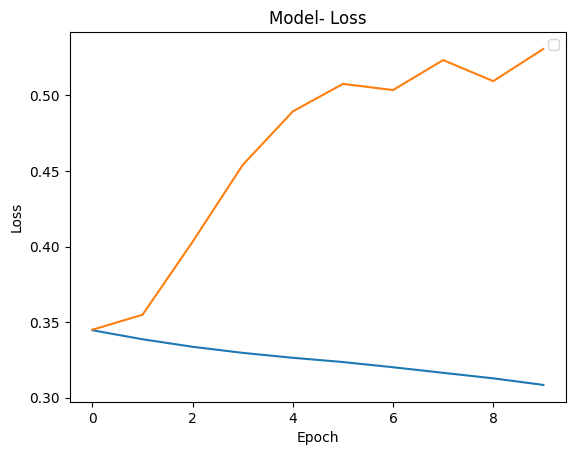

In [68]:
analysis.plot_accuracy_and_loss(history, X_test, Y_test, model)

In [69]:
X_test.shape, Y_test.shape

((2800, 4000), (2800, 2))

In [70]:
Y_pred_onehot = model.predict(X_test)
Y_pred_class = preprocess.onehot_to_class(Y_pred_onehot, num_classes=num_classes)
Y_test_onehot = Y_test.copy()
Y_test_class = preprocess.onehot_to_class(Y_test_onehot, num_classes=num_classes)

# calculate the accuracy for each class
for i in range(num_classes):
    acc = np.sum((Y_test_class == i) & (Y_pred_class == i)) / np.sum(Y_test_class == i)
    print(f"Accuracy for class {i}: {acc:.2f}")

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step
Accuracy for class 0: 1.00
Accuracy for class 1: 0.00


In [71]:
# calculate the confusion matrix based on Y_test_class and Y_pred_class
C = np.zeros((num_classes, num_classes))
for i in range(len(Y_test_class)):
    for j in range(len(Y_test_class[i])):
        C[int(Y_test_class[i][j]), int(Y_pred_class[i][j])] += 1
print("Confusion Matrix:")
print(C)

Confusion Matrix:
[[1.399e+03 1.000e+00]
 [1.397e+03 3.000e+00]]
